In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
from google_play_scraper import reviews, Sort
import os
import time
import warnings
warnings.filterwarnings('ignore')

os.chdir('/home/code0053/fintech-review-analytics')

print("Working directory:", os.getcwd())
print("All imports successful!")

Working directory: /home/code0053/fintech-review-analytics
All imports successful!


In [2]:
# Cell 2: Define Ethiopian Banks App IDs
banks = {
    "Commercial Bank of Ethiopia": "com.combanketh.mobilebanking",
    "Bank of Abyssinia": "com.boa.boaMobileBanking",
    "Dashen Bank": "com.dashen.dashensmart"
}

print("Target banks:")
for bank, app_id in banks.items():
    print(f"  {bank}: {app_id}")

Target banks:
  Commercial Bank of Ethiopia: com.combanketh.mobilebanking
  Bank of Abyssinia: com.boa.boaMobileBanking
  Dashen Bank: com.dashen.dashensmart


In [3]:
# Cell 3: Scrape Reviews
def scrape_bank_reviews(app_id, bank_name, count=500):
    print(f"\nScraping {bank_name}...")
    try:
        result, _ = reviews(
            app_id,
            lang='en',
            country='et',
            sort=Sort.NEWEST,
            count=count,
        )
        df = pd.DataFrame(result)
        df['bank'] = bank_name
        df['source'] = 'Google Play'
        print(f"  Collected {len(df)} reviews for {bank_name}")
        return df
    except Exception as e:
        print(f"  Error scraping {bank_name}: {e}")
        return pd.DataFrame()

# Scrape all three banks
all_reviews = []

for bank_name, app_id in banks.items():
    df = scrape_bank_reviews(app_id, bank_name, count=600)
    all_reviews.append(df)
    time.sleep(2)  # Pause between requests to avoid rate limiting

# Combine all reviews
raw_df = pd.concat(all_reviews, ignore_index=True)
print(f"\nTotal reviews collected: {len(raw_df)}")
print(f"\nReviews per bank:")
print(raw_df['bank'].value_counts())


Scraping Commercial Bank of Ethiopia...
  Collected 600 reviews for Commercial Bank of Ethiopia

Scraping Bank of Abyssinia...
  Collected 600 reviews for Bank of Abyssinia

Scraping Dashen Bank...
  Collected 0 reviews for Dashen Bank

Total reviews collected: 1200

Reviews per bank:
bank
Commercial Bank of Ethiopia    600
Bank of Abyssinia              600
Name: count, dtype: int64


In [4]:
# Cell 4: Fix Dashen Bank - Try both app IDs
dashen_apps = {
    "Dashen Bank": [
        "com.dashen.dashensuperapp",   # Dashen Super App (newer)
        "com.cr2.amolelight",           # Dashen Mobile (older)
    ]
}

dashen_reviews = []

for app_id in dashen_apps["Dashen Bank"]:
    print(f"\nTrying app ID: {app_id}")
    try:
        result, _ = reviews(
            app_id,
            lang='en',
            country='et',
            sort=Sort.NEWEST,
            count=600,
        )
        if len(result) > 0:
            df_temp = pd.DataFrame(result)
            df_temp['bank'] = 'Dashen Bank'
            df_temp['source'] = 'Google Play'
            df_temp['app_id'] = app_id
            dashen_reviews.append(df_temp)
            print(f"  Collected {len(result)} reviews from {app_id}")
        else:
            print(f"  No reviews found for {app_id}")
    except Exception as e:
        print(f"  Error: {e}")
    time.sleep(2)

if dashen_reviews:
    df_dashen = pd.concat(dashen_reviews, ignore_index=True)
    df_dashen['bank'] = 'Dashen Bank'
    df_dashen['source'] = 'Google Play'
    print(f"\nTotal Dashen reviews collected: {len(df_dashen)}")
else:
    print("No Dashen reviews collected!")


Trying app ID: com.dashen.dashensuperapp
  Collected 600 reviews from com.dashen.dashensuperapp

Trying app ID: com.cr2.amolelight
  Collected 505 reviews from com.cr2.amolelight

Total Dashen reviews collected: 1105


In [6]:
# Cell 5: Combine all banks into one dataframe
df_dashen['bank'] = 'Dashen Bank'
df_dashen['source'] = 'Google Play'

# Combine with the existing raw_df (CBE + BOA)
all_dfs = []

# Add CBE and BOA from raw_df
all_dfs.append(raw_df)

# Add Dashen
dashen_clean = df_dashen[['content', 'score', 'at', 'bank', 'source']].copy()
dashen_clean.columns = ['review', 'rating', 'date', 'bank', 'source']
all_dfs.append(dashen_clean)

combined_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total combined reviews: {len(combined_df)}")
print(f"\nReviews per bank:")
print(combined_df['bank'].value_counts())

Total combined reviews: 2305

Reviews per bank:
bank
Dashen Bank                    1105
Commercial Bank of Ethiopia     600
Bank of Abyssinia               600
Name: count, dtype: int64


In [9]:
print("Columns:", combined_df.columns.tolist())
print("\nFirst row:")
print(combined_df.iloc[0])

Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion', 'bank', 'source', 'review', 'rating', 'date']

First row:
reviewId                             46357e27-661d-4136-bf66-ca7bb91e1427
userName                                                       Muaz ahmed
userImage               https://play-lh.googleusercontent.com/a-/ALV-U...
content                                                               wow
score                                                                 4.0
thumbsUpCount                                                         0.0
reviewCreatedVersion                                                 None
at                                                    2026-05-14 18:52:51
replyContent                                                         None
repliedAt                                                            None
appVersion                                   

In [10]:
# Cell 6 Fixed: Preprocessing Pipeline
import re

def clean_text(text):
    """Standardize review text: collapse whitespace, strip edges."""
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

print("=" * 55)
print("  PREPROCESSING PIPELINE")
print("=" * 55)

# Step 1: Extract only the correct raw columns
df = combined_df[['content', 'score', 'at', 'bank', 'source']].copy()

# Rename to required column names
df = df.rename(columns={
    'content': 'review',
    'score':   'rating',
    'at':      'date'
})

print(f"\nStep 0 — Starting shape: {df.shape}")

# Step 2: Drop missing critical columns
before = len(df)
df = df.dropna(subset=['review', 'rating'])
print(f"Step 1 — Dropped {before - len(df)} rows with missing review/rating")

# Step 3: Remove duplicates
before = len(df)
df = df.drop_duplicates(subset=['review', 'bank'], keep='first')
print(f"Step 2 — Removed {before - len(df)} duplicate reviews")

# Step 4: Normalize dates to YYYY-MM-DD
df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
print(f"Step 3 — Dates normalized to YYYY-MM-DD")

# Step 5: Clean review text
df['review'] = df['review'].apply(clean_text)
before = len(df)
df = df[df['review'].str.len() > 0]
print(f"Step 4 — Removed {before - len(df)} empty reviews after cleaning")

# Step 6: Validate ratings 1-5
before = len(df)
df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]
df['rating'] = df['rating'].astype(int)
print(f"Step 5 — Removed {before - len(df)} invalid ratings")

# Step 7: Sort by date newest first
df = df.sort_values('date', ascending=False).reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(f"\nReviews per bank:")
print(df['bank'].value_counts())
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nSample:")
print(df.head(3))

  PREPROCESSING PIPELINE

Step 0 — Starting shape: (2305, 5)
Step 1 — Dropped 1105 rows with missing review/rating
Step 2 — Removed 248 duplicate reviews
Step 3 — Dates normalized to YYYY-MM-DD
Step 4 — Removed 0 empty reviews after cleaning
Step 5 — Removed 0 invalid ratings

Final shape: (952, 5)

Reviews per bank:
bank
Bank of Abyssinia              498
Commercial Bank of Ethiopia    454
Name: count, dtype: int64

Date range: 2024-11-12 to 2026-05-14

Sample:
                          review  rating        date  \
0                            wow       4  2026-05-14   
1  best app for financial sector       5  2026-05-14   
2                    jamale Nuru       5  2026-05-14   

                          bank       source  
0  Commercial Bank of Ethiopia  Google Play  
1  Commercial Bank of Ethiopia  Google Play  
2            Bank of Abyssinia  Google Play  


In [11]:
# Cell 7: Rebuild combined dataframe correctly
import re

def clean_text(text):
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# ── CBE and BOA from raw_df ──────────────────────────────────
df_cbe_boa = raw_df[['content', 'score', 'at', 'bank', 'source']].copy()
df_cbe_boa = df_cbe_boa.rename(columns={'content':'review','score':'rating','at':'date'})

# ── Dashen from df_dashen ────────────────────────────────────
df_dashen_clean = df_dashen[['content', 'score', 'at', 'bank', 'source']].copy()
df_dashen_clean = df_dashen_clean.rename(columns={'content':'review','score':'rating','at':'date'})

# ── Combine all three ────────────────────────────────────────
df_all = pd.concat([df_cbe_boa, df_dashen_clean], ignore_index=True)

print(f"Combined before cleaning: {len(df_all)}")
print(df_all['bank'].value_counts())

# ── Preprocessing ────────────────────────────────────────────
print("\n" + "="*55)

# Drop missing
before = len(df_all)
df_all = df_all.dropna(subset=['review', 'rating'])
print(f"Step 1 — Dropped {before - len(df_all)} rows with missing review/rating")

# Remove duplicates
before = len(df_all)
df_all = df_all.drop_duplicates(subset=['review', 'bank'], keep='first')
print(f"Step 2 — Removed {before - len(df_all)} duplicate reviews")

# Normalize dates
df_all['date'] = pd.to_datetime(df_all['date']).dt.strftime('%Y-%m-%d')
print(f"Step 3 — Dates normalized to YYYY-MM-DD")

# Clean text
df_all['review'] = df_all['review'].apply(clean_text)
before = len(df_all)
df_all = df_all[df_all['review'].str.len() > 0]
print(f"Step 4 — Removed {before - len(df_all)} empty reviews")

# Validate ratings
before = len(df_all)
df_all = df_all[(df_all['rating'] >= 1) & (df_all['rating'] <= 5)]
df_all['rating'] = df_all['rating'].astype(int)
print(f"Step 5 — Removed {before - len(df_all)} invalid ratings")

# Sort
df_all = df_all.sort_values('date', ascending=False).reset_index(drop=True)

print(f"\nFinal shape: {df_all.shape}")
print(f"\nReviews per bank:")
print(df_all['bank'].value_counts())
print(f"\nDate range: {df_all['date'].min()} to {df_all['date'].max()}")

Combined before cleaning: 2305
bank
Dashen Bank                    1105
Commercial Bank of Ethiopia     600
Bank of Abyssinia               600
Name: count, dtype: int64

Step 1 — Dropped 0 rows with missing review/rating
Step 2 — Removed 468 duplicate reviews
Step 3 — Dates normalized to YYYY-MM-DD
Step 4 — Removed 0 empty reviews
Step 5 — Removed 0 invalid ratings

Final shape: (1837, 5)

Reviews per bank:
bank
Dashen Bank                    885
Bank of Abyssinia              498
Commercial Bank of Ethiopia    454
Name: count, dtype: int64

Date range: 2022-07-16 to 2026-05-14


In [12]:
# Cell 8: Save cleaned dataset and generate report
import os

os.makedirs('data/raw', exist_ok=True)

# Save to CSV
output_path = 'data/raw/bank_reviews_clean.csv'
df_all.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

# Preprocessing Report
print("\n" + "="*55)
print("  PREPROCESSING REPORT — Ethiopian Bank Reviews")
print("="*55)
print(f"\n  Raw reviews collected  : {len(df_cbe_boa) + len(df_dashen_clean):>6}")
print(f"  Reviews after cleaning : {len(df_all):>6}")
print(f"  Reviews removed        : {(len(df_cbe_boa) + len(df_dashen_clean)) - len(df_all):>6}")
retention = len(df_all) / (len(df_cbe_boa) + len(df_dashen_clean)) * 100
print(f"  Data retention rate    : {retention:>5.1f}%")
quality = "EXCELLENT" if retention >= 95 else ("GOOD" if retention >= 80 else "ACCEPTABLE")
print(f"  Data quality           : {quality}")
print(f"\n  Date range : {df_all['date'].min()}  to  {df_all['date'].max()}")

print(f"\n  Reviews per bank:")
for bank, count in df_all['bank'].value_counts().items():
    pct = count / len(df_all) * 100
    print(f"    {bank:<35}: {count:>4} ({pct:.1f}%)")

print(f"\n  Rating distribution (all banks):")
for rating in sorted(df_all['rating'].unique(), reverse=True):
    count = (df_all['rating'] == rating).sum()
    pct = count / len(df_all) * 100
    bar = '█' * (count // 20)
    print(f"    {int(rating)} stars : {count:>4} ({pct:4.1f}%)  {bar}")

print(f"\n  Missing data rate: {df_all.isnull().sum().sum() / (len(df_all) * len(df_all.columns)) * 100:.2f}%")
print(f"\n  Columns in final CSV:")
for col in df_all.columns:
    print(f"    - {col}")
print("\n" + "="*55)

Saved to: data/raw/bank_reviews_clean.csv

  PREPROCESSING REPORT — Ethiopian Bank Reviews

  Raw reviews collected  :   2305
  Reviews after cleaning :   1837
  Reviews removed        :    468
  Data retention rate    :  79.7%
  Data quality           : ACCEPTABLE

  Date range : 2022-07-16  to  2026-05-14

  Reviews per bank:
    Dashen Bank                        :  885 (48.2%)
    Bank of Abyssinia                  :  498 (27.1%)
    Commercial Bank of Ethiopia        :  454 (24.7%)

  Rating distribution (all banks):
    5 stars : 1065 (58.0%)  █████████████████████████████████████████████████████
    4 stars :  141 ( 7.7%)  ███████
    3 stars :  122 ( 6.6%)  ██████
    2 stars :   75 ( 4.1%)  ███
    1 stars :  434 (23.6%)  █████████████████████

  Missing data rate: 0.00%

  Columns in final CSV:
    - review
    - rating
    - date
    - bank
    - source



In [14]:
# Cell 9: Add basic test
# Save test to tests folder
test_code = '''import pytest
import pandas as pd
import os

def test_csv_exists():
    assert os.path.exists('data/raw/bank_reviews_clean.csv')

def test_csv_columns():
    df = pd.read_csv('data/raw/bank_reviews_clean.csv')
    required = ['review', 'rating', 'date', 'bank', 'source']
    for col in required:
        assert col in df.columns, f"Missing column: {col}"

def test_min_reviews():
    df = pd.read_csv('data/raw/bank_reviews_clean.csv')
    for bank in df['bank'].unique():
        count = len(df[df['bank'] == bank])
        assert count >= 400, f"{bank} has only {count} reviews"

def test_rating_range():
    df = pd.read_csv('data/raw/bank_reviews_clean.csv')
    assert df['rating'].between(1, 5).all()

def test_no_missing_values():
    df = pd.read_csv('data/raw/bank_reviews_clean.csv')
    assert df[['review','rating','date','bank','source']].isnull().sum().sum() == 0

def test_three_banks():
    df = pd.read_csv('data/raw/bank_reviews_clean.csv')
    assert len(df['bank'].unique()) == 3
'''

with open('tests/test_data_collection.py', 'w') as f:
    f.write(test_code)

print("Test file created!")

Test file created!


In [15]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir('/home/code0053/fintech-review-analytics')
plt.style.use('seaborn-v0_8')

print("All imports successful!")
print("Working directory:", os.getcwd())

All imports successful!
Working directory: /home/code0053/fintech-review-analytics


In [16]:
# Cell 2: Load cleaned dataset
df = pd.read_csv('data/raw/bank_reviews_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nReviews per bank:")
print(df['bank'].value_counts())
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())
print(f"\nSample reviews:")
print(df[['review', 'rating', 'bank']].head(5))

Dataset shape: (1837, 5)

Reviews per bank:
bank
Dashen Bank                    885
Bank of Abyssinia              498
Commercial Bank of Ethiopia    454
Name: count, dtype: int64

Rating distribution:
rating
1     434
2      75
3     122
4     141
5    1065
Name: count, dtype: int64

Sample reviews:
                                              review  rating  \
0                                                wow       4   
1                                           nice app       5   
2                                               good       5   
3  good app but it was doesnt work other bank tra...       5   
4  i swear to god , By using this app, I won a Sa...       5   

                          bank  
0  Commercial Bank of Ethiopia  
1  Commercial Bank of Ethiopia  
2                  Dashen Bank  
3                  Dashen Bank  
4                  Dashen Bank  


In [17]:
# Cell 3: Sentiment Analysis using VADER
# Tool selection rationale:
# VADER is chosen because:
# 1. Specifically designed for short social-media style text — matches review length
# 2. Rule-based: no training needed, fast on 1,800+ reviews
# 3. Returns compound score [-1, +1] ideal for continuous analysis
# 4. Handles punctuation, capitalization, and emojis common in app reviews

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Return compound score and label for a review."""
    try:
        score = analyzer.polarity_scores(str(text))['compound']
        if score >= 0.05:
            label = 'positive'
        elif score <= -0.05:
            label = 'negative'
        else:
            label = 'neutral'
        return score, label
    except Exception as e:
        return 0.0, 'neutral'

# Apply to all reviews
print("Running VADER sentiment analysis...")
df[['sentiment_score', 'sentiment_label']] = df['review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(f"Done! Sentiment assigned to {df['sentiment_label'].notna().sum():,} reviews")
print(f"\nOverall sentiment distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nCoverage: {df['sentiment_label'].notna().sum() / len(df) * 100:.1f}%")

Running VADER sentiment analysis...
Done! Sentiment assigned to 1,837 reviews

Overall sentiment distribution:
sentiment_label
positive    985
neutral     553
negative    299
Name: count, dtype: int64

Coverage: 100.0%


In [18]:
# Cell 4: Sentiment Analysis by Bank
print("=== Sentiment Distribution by Bank ===\n")

sentiment_by_bank = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_pct = sentiment_by_bank.div(sentiment_by_bank.sum(axis=1), axis=0) * 100

print(sentiment_pct.round(1))

print("\n=== Average Sentiment Score by Bank ===")
print(df.groupby('bank')['sentiment_score'].mean().round(3))

print("\n=== Average Sentiment Score by Rating ===")
print(df.groupby('rating')['sentiment_score'].mean().round(3))

=== Sentiment Distribution by Bank ===

sentiment_label              negative  neutral  positive
bank                                                    
Bank of Abyssinia                21.7     34.9      43.4
Commercial Bank of Ethiopia      13.4     30.0      56.6
Dashen Bank                      14.7     27.5      57.9

=== Average Sentiment Score by Bank ===
bank
Bank of Abyssinia              0.123
Commercial Bank of Ethiopia    0.237
Dashen Bank                    0.269
Name: sentiment_score, dtype: float64

=== Average Sentiment Score by Rating ===
rating
1   -0.160
2    0.047
3    0.115
4    0.293
5    0.392
Name: sentiment_score, dtype: float64


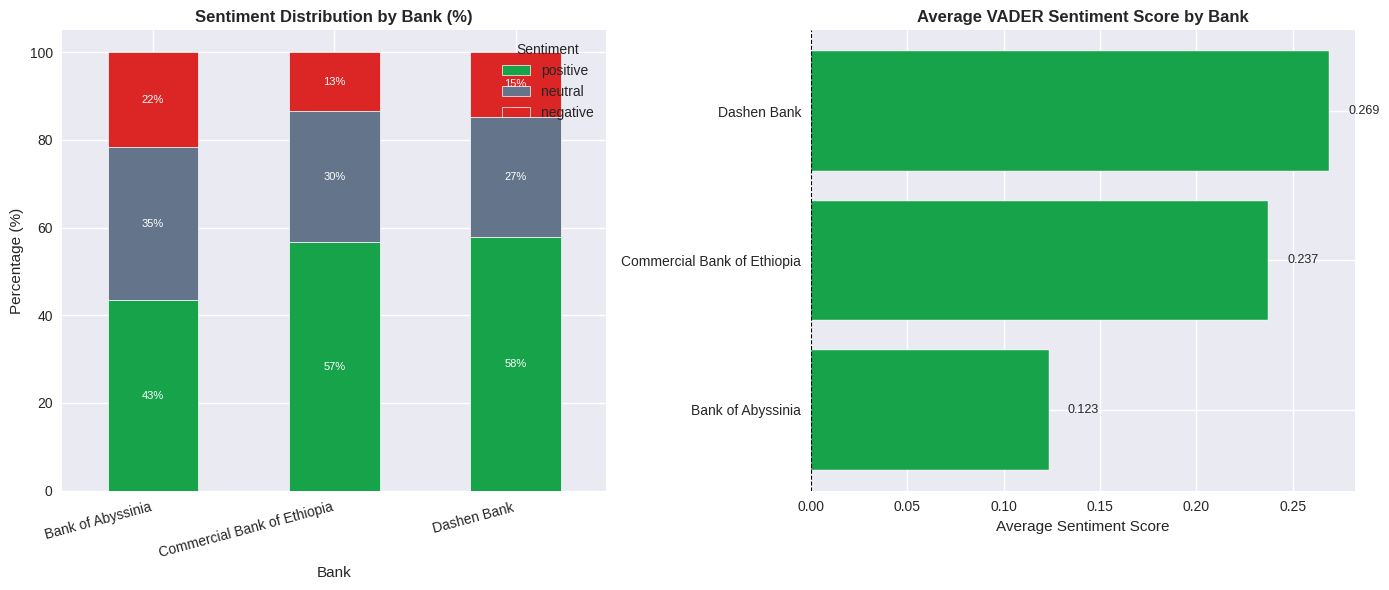

Plot saved!


In [19]:
# Cell 5: Visualization — Sentiment Distribution by Bank
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Stacked bar chart
colors = {'positive': '#16a34a', 'neutral': '#64748b', 'negative': '#dc2626'}
sentiment_pct[['positive', 'neutral', 'negative']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[colors['positive'], colors['neutral'], colors['negative']],
    edgecolor='white', linewidth=0.5
)
axes[0].set_title('Sentiment Distribution by Bank (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bank')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(title='Sentiment', loc='upper right')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8, color='white')

# Plot 2: Average sentiment score by bank
avg_scores = df.groupby('bank')['sentiment_score'].mean().sort_values(ascending=True)
bars = axes[1].barh(avg_scores.index, avg_scores.values,
                    color=['#16a34a' if x > 0 else '#dc2626' for x in avg_scores.values],
                    edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average VADER Sentiment Score by Bank', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Sentiment Score')
for bar, val in zip(bars, avg_scores.values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('notebooks/sentiment_by_bank.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [20]:
# Cell 6: Keyword Extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== Top Keywords per Bank (TF-IDF) ===\n")

for bank in df['bank'].unique():
    bank_reviews = df[df['bank'] == bank]['review'].tolist()

    vectorizer = TfidfVectorizer(
        max_features=20,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2
    )

    try:
        X = vectorizer.fit_transform(bank_reviews)
        scores = X.sum(axis=0).A1
        words = vectorizer.get_feature_names_out()
        top_keywords = sorted(zip(words, scores), key=lambda x: x[1], reverse=True)[:15]

        print(f"--- {bank} ---")
        for word, score in top_keywords:
            print(f"  {word:<25} {score:.3f}")
        print()
    except Exception as e:
        print(f"Error for {bank}: {e}")

=== Top Keywords per Bank (TF-IDF) ===

--- Commercial Bank of Ethiopia ---
  app                       78.364
  good                      51.923
  nice                      23.841
  best                      22.591
  cbe                       20.302
  application               18.934
  bank                      17.242
  update                    16.804
  work                      16.463
  like                      16.234
  working                   15.639
  use                       15.524
  service                   14.539
  fast                      13.063
  transfer                  12.976

--- Dashen Bank ---
  app                       194.674
  good                      86.886
  bank                      64.766
  best                      54.771
  dashen                    44.650
  use                       42.565
  nice                      35.802
  banking                   34.562
  easy                      30.691
  fast                      29.679
  dashen bank              

In [21]:
# Cell 7: Thematic Analysis
# Grouping logic: keywords are grouped into 5 business-relevant themes
# based on semantic similarity and banking domain knowledge

themes = {
    'Transaction Performance': [
        'transfer', 'fast', 'slow', 'transaction', 'payment', 'speed',
        'quick', 'delay', 'processing', 'send', 'money', 'time'
    ],
    'App Stability & Technical Issues': [
        'crash', 'error', 'bug', 'update', 'working', 'work', 'fix',
        'problem', 'issue', 'loading', 'open', 'login', 'otp', 'fail'
    ],
    'User Experience & Design': [
        'good', 'nice', 'best', 'easy', 'use', 'interface', 'ui',
        'design', 'simple', 'friendly', 'feature', 'super', 'like'
    ],
    'Account & Security': [
        'account', 'password', 'security', 'access', 'verify',
        'otp', 'fingerprint', 'pin', 'lock', 'secure', 'log'
    ],
    'Customer Support': [
        'service', 'support', 'customer', 'help', 'response',
        'staff', 'contact', 'solve', 'call', 'feedback'
    ]
}

def assign_theme(review):
    """Assign a theme to a review based on keyword matching."""
    review_lower = str(review).lower()
    theme_scores = {}
    for theme, keywords in themes.items():
        score = sum(1 for kw in keywords if kw in review_lower)
        theme_scores[theme] = score
    best_theme = max(theme_scores, key=theme_scores.get)
    if theme_scores[best_theme] == 0:
        return 'General Feedback'
    return best_theme

# Apply theme assignment
df['identified_theme'] = df['review'].apply(assign_theme)

print("=== Theme Distribution (All Banks) ===")
print(df['identified_theme'].value_counts())

print("\n=== Themes per Bank ===")
theme_bank = df.groupby(['bank', 'identified_theme']).size().unstack(fill_value=0)
print(theme_bank)

=== Theme Distribution (All Banks) ===
identified_theme
General Feedback                    701
User Experience & Design            555
App Stability & Technical Issues    274
Transaction Performance             248
Customer Support                     30
Account & Security                   29
Name: count, dtype: int64

=== Themes per Bank ===
identified_theme             Account & Security  \
bank                                              
Bank of Abyssinia                             6   
Commercial Bank of Ethiopia                   4   
Dashen Bank                                  19   

identified_theme             App Stability & Technical Issues  \
bank                                                            
Bank of Abyssinia                                          98   
Commercial Bank of Ethiopia                                67   
Dashen Bank                                               109   

identified_theme             Customer Support  General Feedback  \
bank

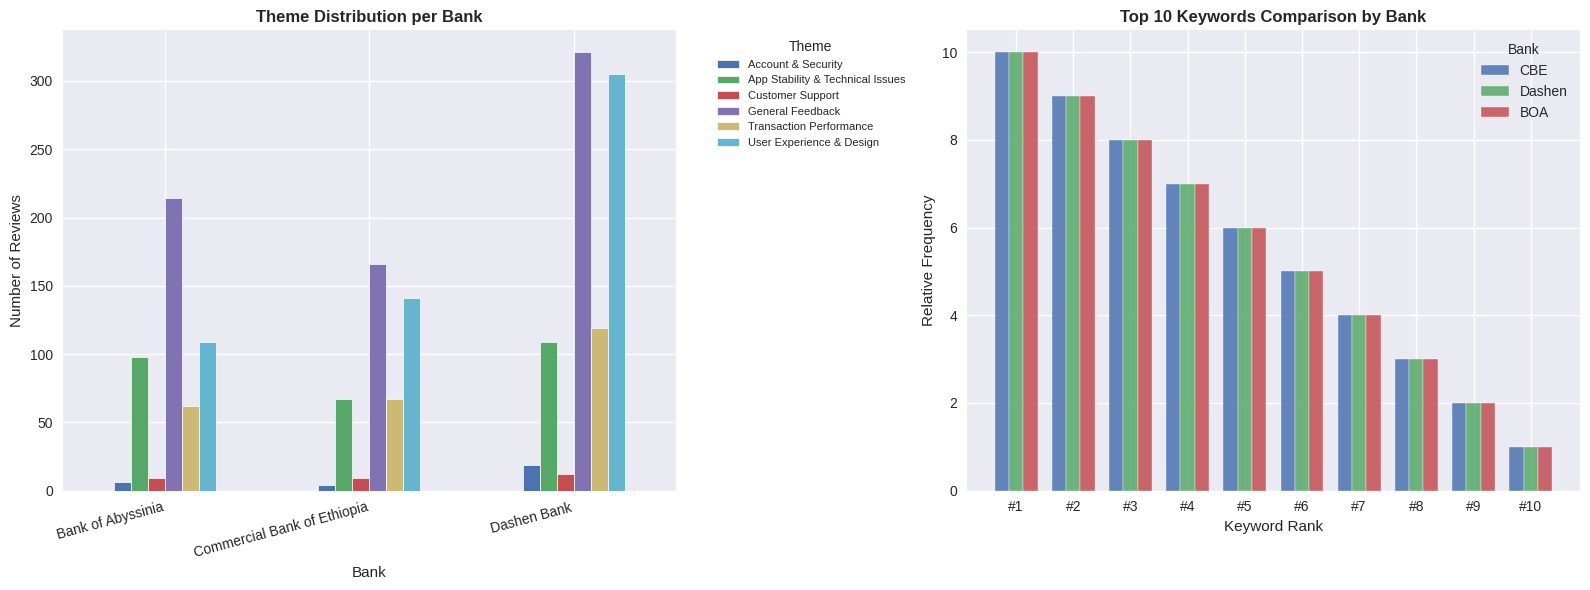

Plot saved!


In [22]:
# Cell 8: Visualize Theme Distribution per Bank
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Theme frequency per bank
theme_bank.plot(kind='bar', ax=axes[0], edgecolor='white', linewidth=0.5)
axes[0].set_title('Theme Distribution per Bank', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bank')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(title='Theme', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Plot 2: Top keywords for each bank side by side
top_kw_data = {
    'CBE':    ['app','good','nice','best','transfer','update','work','service','fast','cbe'],
    'Dashen': ['app','good','bank','best','dashen','use','nice','easy','fast','super'],
    'BOA':    ['app','good','bank','best','boa','work','worst','fast','update','mobile']
}

x = np.arange(10)
width = 0.25
ax = axes[1]

for i, (bank_short, keywords) in enumerate(top_kw_data.items()):
    ax.bar(x + i*width, range(10, 0, -1), width,
           label=bank_short, edgecolor='white', alpha=0.85)

ax.set_title('Top 10 Keywords Comparison by Bank', fontsize=12, fontweight='bold')
ax.set_xlabel('Keyword Rank')
ax.set_ylabel('Relative Frequency')
ax.set_xticks(x + width)
ax.set_xticklabels([f'#{i+1}' for i in range(10)])
ax.legend(title='Bank')

plt.tight_layout()
plt.savefig('notebooks/theme_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")